# 03-3 특성 공학과 규제(Ridgo, Lasso) (1)

#특성공학이란? 기존데이터를 변형하거나 조합하여 새로운 특성(feature)을 만드는 것
#다중회귀? 여러개의 특성을 사용하는 선형회귀

In [12]:
import pandas as pd


In [13]:
#데이터 가져오기
df=pd.read_csv('./data/perch_full.csv')
df.head()


,length,height,width
0,8.4,2.11,1.41
1,13.7,3.53,2.00
2,15.0,3.82,2.43
3,16.2,4.59,2.63
4,17.4,4.59,2.94


In [3]:
perch_ful=df.to_numpy() #데이터프레임형식=>넘파이 배열
perch_ful

array([[ 8.4 ,  2.11,  1.41],
       [13.7 ,  3.53,  2.  ],
       [15.  ,  3.82,  2.43],
       [16.2 ,  4.59,  2.63],
       [17.4 ,  4.59,  2.94],
       [18.  ,  5.22,  3.32],
       [18.7 ,  5.2 ,  3.12],
       [19.  ,  5.64,  3.05],
       [19.6 ,  5.14,  3.04],
       [20.  ,  5.08,  2.77],
       [21.  ,  5.69,  3.56],
       [21.  ,  5.92,  3.31],
       [21.  ,  5.69,  3.67],
       [21.3 ,  6.38,  3.53],
       [22.  ,  6.11,  3.41],
       [22.  ,  5.64,  3.52],
       [22.  ,  6.11,  3.52],
       [22.  ,  5.88,  3.52],
       [22.  ,  5.52,  4.  ],
       [22.5 ,  5.86,  3.62],
       [22.5 ,  6.79,  3.62],
       [22.7 ,  5.95,  3.63],
       [23.  ,  5.22,  3.63],
       [23.5 ,  6.28,  3.72],
       [24.  ,  7.29,  3.72],
       [24.  ,  6.38,  3.82],
       [24.6 ,  6.73,  4.17],
       [25.  ,  6.44,  3.68],
       [25.6 ,  6.56,  4.24],
       [26.5 ,  7.17,  4.14],
       [27.3 ,  8.32,  5.14],
       [27.5 ,  7.17,  4.34],
       [27.5 ,  7.05,  4.34],
       [27

In [14]:

import numpy as np

#타깃 데이터
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 
     1000.0, 1000.0]
     )

In [15]:
from sklearn.model_selection import train_test_split
train_input,test_input,train_target,test_target=train_test_split(perch_ful, perch_weight, random_state=42)

In [16]:
train_input.shape,test_input.shape,train_target.shape,test_target.shape

((42, 3), (14, 3), (42,), (14,))

# 사이킷런의 변환기(Transformer)
- PolynomialFeatures
- 자동으로 다항 특성을 만들어주는 도구

In [19]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(include_bias=False)
poly.fit([[2,3]]) #훈련 2,3 아무거나 넣어서 알아봄
poly.transform([[2,3]]) # 변환: 제고하거나 서로 곱하여 새로운 데이터를 만들어 준다. 특성이 많아짐
#PolynomialFeatures: 특성을조합해서 다항식 형태의 새로운 특성들을 만들어주는 도구
#degreee=2: 다항식의 최고 차수를 몇 차까지 생성할지를 설정하는 옵션, 기본값

#1은 절편이다. 사이킷런의 선형 모델은 자동으로 절편을 추가하므로 굳이 이렇게 특성을 만들 필요가 없다.
#include_bias=False: 맨앞의 1(상수항)은 빼고 출력
#2,3은 주어진것, 2*2=4, 3*3=9, 2*3=6을 만듬

array([[2., 3., 4., 6., 9.]])

In [20]:
train_input.shape

(42, 3)

In [21]:
poly=PolynomialFeatures(include_bias=False)
poly.fit(train_input)
train_poly=poly.transform(train_input)
train_poly.shape

(42, 9)

In [23]:
#PolynomialFeatures가 만들어낸 각 특성의 이름을 문자열로 알려주는 함수
poly.get_feature_names_out()

array(['x0', 'x1', 'x2', 'x0^2', 'x0 x1', 'x0 x2', 'x1^2', 'x1 x2',
       'x2^2'], dtype=object)

In [24]:
test_poly=poly.transform(test_input)

## 다중회귀 모델 훈련하기

In [25]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(train_poly,train_target)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
lr.score(train_poly, train_target)

0.9903183436982126

In [27]:
lr.score(test_poly, test_target)

0.9714559911594125

# 특성을 더 추가하면 어떻게 될까? 3제곱, 4제곱을 넣으면
- PolynomialFeatures클래스의 degree매개변수를 사용하여 필요한 고차항의 최대 차수를 지정할 수 있다. 

In [28]:
# degree 5는 엉망이고 2는 적합
poly=PolynomialFeatures(degree=5, include_bias=False)
poly.fit(train_input)
train_poly=poly.transform(train_input)
test_poly=poly.transform(test_input)
train_poly.shape

(42, 55)

In [29]:
# 훈련점수 
lr.fit(train_poly,train_target)
lr.score(train_poly,train_target)

0.9999999999997232

In [30]:
lr.score(test_poly, test_target)

-144.40564483377855

#훈련세트는 거의완벽하게 학습했는데 테스는 형편없는 점수가 나왔다.
#셈플수가 42개이고 특성이 55개이므로 완벽하게 학습할 수 있었음. 
#훈련세트에 너무 과대적합되었다. => 과대적합을 줄이는 방법 ->규제

# 5️⃣ 규제 (Regularization)

## 규제란?

> 모델이 너무 복잡해지지 않도록 계수를 제한하는 것
>

In [31]:
#규제: 표준점수로 바꾼다.
#transform()을 사용하기전 사용하는 것이 바람직하다.
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_poly)
train_scaled=ss.transform(train_poly)
test_scaled=ss.transform(test_poly)
train_scaled


array([[-1.01339619, -1.01007487, -1.01952321, ..., -0.76449499,
        -0.75967179, -0.75143746],
       [-0.73842893, -0.75254307, -0.74466913, ..., -0.73198449,
        -0.72731765, -0.71950111],
       [-1.11650891, -0.98919391, -0.97371419, ..., -0.76114089,
        -0.75592147, -0.74734146],
       ...,
       [-0.32597805, -0.51589222, -0.33238802, ..., -0.65673421,
        -0.64237495, -0.62509499],
       [ 1.55296488,  1.65572732,  1.17358328, ...,  1.45958191,
         1.19906225,  0.95977016],
       [ 0.6936922 ,  0.7717668 ,  0.8987292 , ...,  0.3701756 ,
         0.40321427,  0.43089551]], shape=(42, 55))

- 릿지는 계수를 제곱한 값을 기준으로 규제를 적용함(더 선호함)
- 라쏘는 계수의 절대값을 기준으로 규제를 적용함

In [32]:
# 릿지회귀(ridge regreassion)

from sklearn.linear_model import Ridge
ridge=Ridge()
ridge.fit(train_scaled,train_target)
ridge.score(train_scaled,train_target)

0.9896101671037343

In [34]:

ridge.score(test_scaled,test_target)

0.9790693977615387

# alpha의미
| alpha ↑ | 규제 강함 |

| alpha ↓ | 규제 약함 |

In [35]:
import matplotlib.pylab as plt
from sklearn.linear_model import Ridge

# alpha 값을 저장할 리스트
train_score = []
test_score = []

# alpha를 10의 배수로 설정 (관례)
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]

# alpha 값을 바꾸면서 모델 훈련
for alpha in alpha_list:
    ridge = Ridge(alpha=alpha)
    ridge.fit(train_scaled, train_target)

    train_score.append(ridge.score(train_scaled, train_target))
    test_score.append(ridge.score(test_scaled, test_target))

In [36]:
train_score

[0.9930455252088248,
 0.991780998125052,
 0.9903815817570367,
 0.9896101671037343,
 0.988728468997471,
 0.9841843235774494]

In [37]:
test_score

[0.9569388961567329,
 0.9800187936871725,
 0.9827976465386928,
 0.9790693977615387,
 0.9725329582461569,
 0.9627042641050291]

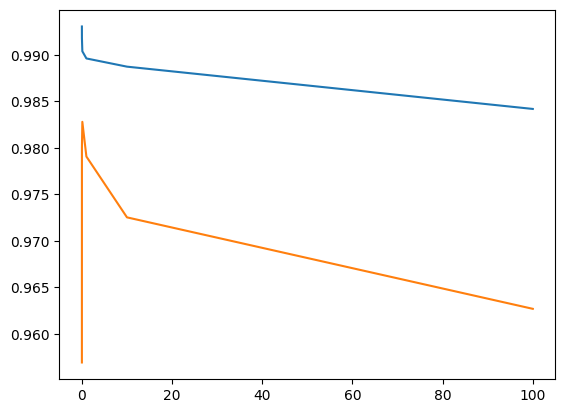

In [38]:
import matplotlib.pyplot as plt
plt.plot(alpha_list, train_score)
plt.plot(alpha_list, test_score)




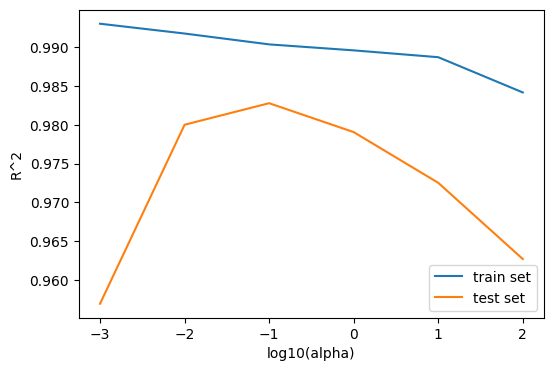

In [104]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(np.log10(alpha_list),train_score, label='train set')
plt.plot(np.log10(alpha_list),test_score, label='test set')
plt.xlabel('log10(alpha)')
plt.ylabel('R^2')
plt.legend()

plt.show()


In [ ]:
#기장 적절한 aplph값은 두 그래프가 가장 가깝고 테스트 세트의 점수가 가장 높은 -1, 즉 10-1승=0.1이다
#alpha값을 0.1로 하여 최종 모델을 훈련한다.


In [39]:
ridge=Ridge(alpha=0.1)
ridge.fit(train_scaled,train_target)
#훈련세트
ridge.score(train_scaled,train_target)

0.9903815817570367

In [40]:
#테스트세트
ridge.score(test_scaled,test_target)

0.9827976465386928

# 라쏘 회귀(Lasso regression)

In [41]:
from sklearn.linear_model import Lasso
lasso=Lasso()
lasso.fit(train_scaled,train_target)
lasso.score(train_scaled,train_target)

0.989789897208096

In [147]:
lasso.score(test_scaled,test_target)

0.9800593698421884

In [43]:
train_score=[]
test_score=[]
alpha_list=[0.001, 0.01, 0.1, 1, 10, 100]

for alpha in alpha_list:
    lasso=Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(train_scaled,train_target)
    train_score.append(lasso.score(train_scaled, train_target))
    test_score.append(lasso.score(test_scaled, test_target))

#Lasso는 반복최적화 알고리즘을 사용해서 모델을 학습
#기본값은 max_iter=1000
#데이터가 복잡하거나 alpha값이 너무 작거나 크면 1000번 안에 안끝날 수 있음
#max_iter=1000이렇게 넉넉하게 주는게 일반적인 관행임

c:\Users\06pc-00\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.878e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\06pc-00\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.297e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(


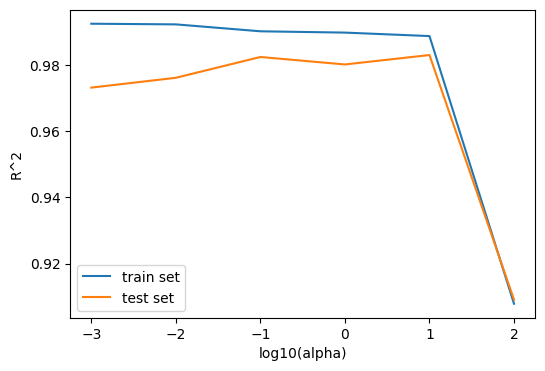

In [44]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(np.log10(alpha_list),train_score, label='train set')
plt.plot(np.log10(alpha_list),test_score, label='test set')
plt.xlabel('log10(alpha)')
plt.ylabel('R^2')
plt.legend()

plt.show()


In [45]:
lasso=Lasso(alpha=10)
lasso.fit(train_scaled,train_target)
#훈련세트
lasso.score(train_scaled,train_target)

0.9888067471131866

In [46]:
lasso.score(test_scaled,test_target)

0.9824470598706695

In [47]:
#특성을 55개나 줬는데 모두 사용했을까? 라쏘 모델의 계수는 coef_속성에 저장되어 있다.
#이중에 0인것을 세어보자
np.sum(lasso.coef_==0)

np.int64(40)

In [48]:
#위에 0이 40개라는 것은 55개의 특성중 15개를 사용하였다는 것이다. 
#라소모델은 유효한 특성을 골라내는 용도로도 사용할 수 있다. 

In [49]:
lasso.coef_

array([ 0.        ,  0.        ,  0.        , 12.14852453, 55.44856399,
       42.23100799,  0.        ,  0.        , 13.70596191,  0.        ,
       43.2185952 ,  5.7033775 , 47.46254536,  7.42309425, 11.85823365,
        0.        ,  0.        , 13.53038193, 21.22111356,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       18.66993032,  0.        ,  0.        ,  0.        , 15.81041778,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        , 18.14672268,
        0.        ,  0.        ,  0.        ,  0.        , 15.51272953,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ])

In [ ]:
# ### 문제 1

# # PolynomialFeatures가 자동으로 만들어주는 특성은 무엇인가?
# 자동으로 다항 특성을 만들어주는 도구, 특성을조합해서 다항식 형태의 새로운 특성들을 만들어준다
#기존 특성들의 거듭제곱과 특성 간의 곱(상호작용 특성)을 자동으로 생성하낟.

In [ ]:
# ### 문제 2

# 왜 규제를 사용할 때 스케일링이 필요한가?
# 규제는 계수의 크기를 기준으로 별점을 주기 때문에 , 특성의 크기가 다르면 공정하기 않기 때문이다. 
# 1️⃣ 규제는 계수 크기에 패널티를 주기 때문
# 2️⃣ 변수 스케일이 다르면 계수 크기가 왜곡됨
# 3️⃣ 그 결과 특정 변수만 과도하게 규제됨
# 4️⃣ 스케일링을 하면 공정한 규제가 가능

In [ ]:
# ### 문제 3

# Ridge와 Lasso의 가장 큰 차이점은?
# 라쏘는 일부 계수를 0으로 만들어 특성 선택을 하지만, 리지는 계수를 0에 가깝게 만 줄인다. 
# Ridge는 계수를 작게 만들지만 0으로 만들지는 않고,
# Lasso는 일부 계수를 0으로 만들어 변수 선택(feature selection)을 수행한다.

In [ ]:
# ### 문제 4

# alpha 값을 0에 가깝게 하면 어떻게 되는가?
# α(alpha) 는 규제의 강도를 조절하는 값입니다.
#α 값을 0에 가깝게 하면 규제가 거의 적용되지 않아 Ridge나 Lasso 모델은 일반 선형회귀와 동일해진다.